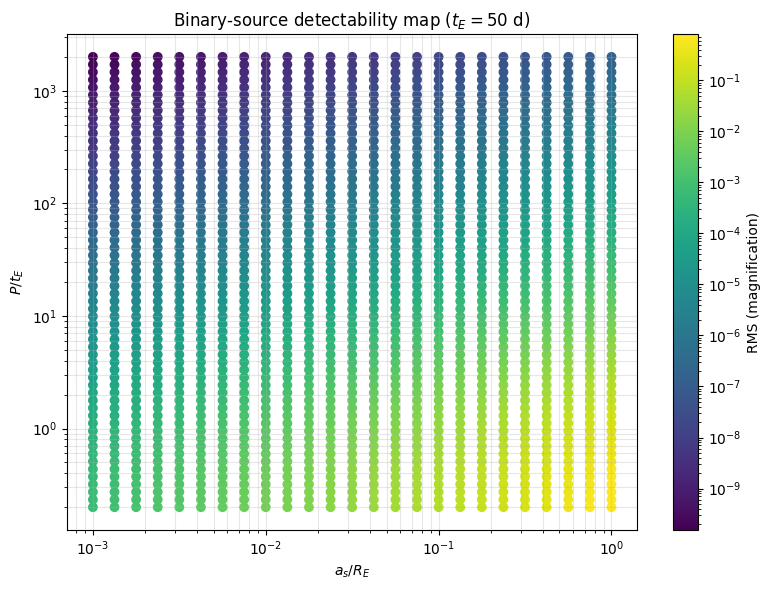

In [5]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ============================================================
# Parámetros de la grilla original
# ============================================================
tE_true = 50.0
rEhat = 5.0  # AU, no se usa directamente en el plot pero lo dejo por claridad

# Esta grilla DEBE ser la misma que usaste al generar los archivos
a_over_RE_grid = np.logspace(-3, 0, 25)

# Directorio con los .npz
pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_P_tE{int(tE_true)}/scan_aRE_*_P_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Función para extraer índices del nombre del archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e ip desde nombres tipo:
    scan_aRE_003_P_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_P_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    ip = int(m.group(2))
    return ia, ip

# ============================================================
# Leer todos los puntos válidos
# ============================================================
x_vals = []
y_vals = []
z_vals = []

for fn in files:
    ia, ip = extract_indices_from_filename(fn)

    if ia < 0 or ia >= len(a_over_RE_grid):
        continue

    a_over_RE = float(a_over_RE_grid[ia])

    d = np.load(fn, allow_pickle=False)

    P_grid = d["P_grid"].astype(float)
    RMS = d["RMS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    # En este esquema cada archivo debería tener un único punto en P
    m = SUCCESS & np.isfinite(P_grid) & np.isfinite(RMS)
    if not np.any(m):
        continue

    P_valid = P_grid[m]
    RMS_valid = RMS[m]

    # Si hay más de un punto por archivo, toma el primero válido
    P_day = float(P_valid[0])
    rms_val = float(RMS_valid[0])

    x_vals.append(a_over_RE)
    y_vals.append(P_day / tE_true)
    z_vals.append(rms_val)

x_vals = np.array(x_vals, dtype=float)
y_vals = np.array(y_vals, dtype=float)
z_vals = np.array(z_vals, dtype=float)

if len(x_vals) == 0:
    raise RuntimeError("No encontré puntos válidos para graficar.")

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Normalización logarítmica para RMS
positive = z_vals[z_vals > 0]
if len(positive) == 0:
    raise RuntimeError("Todos los valores de RMS son <= 0; no puedo usar LogNorm.")

norm = colors.LogNorm(vmin=np.min(positive), vmax=np.max(positive))

sc = ax.scatter(
    x_vals,
    y_vals,
    c=z_vals,
    cmap="viridis",
    norm=norm,
    s=50,
    edgecolors="none"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$a_s/R_E$")
ax.set_ylabel(r"$P/t_E$")
ax.set_title(rf"Binary-source detectability map ($t_E={tE_true:.0f}\ \mathrm{{d}}$)")

ax.grid(True, which="both", alpha=0.3)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"RMS (magnification)")

plt.tight_layout()
plt.show()

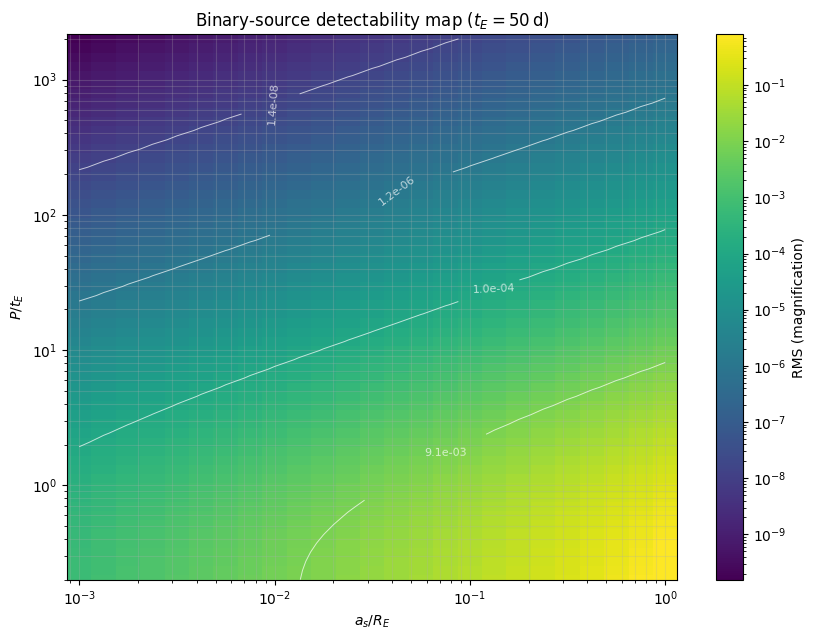

In [6]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ============================================================
# Parámetros de la grilla original
# ============================================================
tE_true = 50.0

# Estas grillas DEBEN ser las mismas que usaste al generar los archivos
a_over_RE_grid = np.logspace(-3, 0, 25)   # eje x
P_grid_days = np.logspace(1, 5, 60)       # período en días
P_over_tE_grid = P_grid_days / tE_true    # eje y

# Directorio con los .npz
pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_P_tE{int(tE_true)}/scan_aRE_*_P_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Función para extraer índices desde el nombre del archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e ip desde nombres tipo:
    scan_aRE_003_P_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_P_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    ip = int(m.group(2))
    return ia, ip

# ============================================================
# [BLOQUE AGREGADO 1]
# Reconstrucción de la matriz 2D
# ============================================================
Na = len(a_over_RE_grid)
Np = len(P_over_tE_grid)

RMS_map = np.full((Na, Np), np.nan, dtype=float)

for fn in files:
    ia, ip = extract_indices_from_filename(fn)

    if not (0 <= ia < Na and 0 <= ip < Np):
        continue

    d = np.load(fn, allow_pickle=False)

    P_grid_file = d["P_grid"].astype(float)
    RMS = d["RMS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid_file) & np.isfinite(RMS)
    if not np.any(m):
        continue

    # Como cada archivo debería corresponder a un solo P, tomo el primero válido
    rms_val = float(RMS[m][0])
    RMS_map[ia, ip] = rms_val

# ============================================================
# [BLOQUE AGREGADO 2]
# Función para calcular bordes de bins en escala log
# útil para pcolormesh con ejes logarítmicos
# ============================================================
def log_bin_edges(x):
    """
    Devuelve los bordes de bins para una grilla x positiva y monótona,
    asumiendo espaciado aproximadamente logarítmico.
    """
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores de x deben ser > 0 para log_bin_edges.")

    lx = np.log10(x)

    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])

    return 10**edges

a_edges = log_bin_edges(a_over_RE_grid)
p_edges = log_bin_edges(P_over_tE_grid)

# pcolormesh espera matriz con shape (Ny, Nx)
Z = RMS_map.T   # ahora shape = (Np, Na)

# ============================================================
# Preparar normalización logarítmica
# ============================================================
positive = Z[np.isfinite(Z) & (Z > 0)]
if len(positive) == 0:
    raise RuntimeError("No hay valores positivos de RMS para usar LogNorm.")

norm = colors.LogNorm(vmin=np.min(positive), vmax=np.max(positive))

# ============================================================
# [BLOQUE AGREGADO 3]
# Figura tipo mapa prolijo
# ============================================================
fig, ax = plt.subplots(figsize=(8.5, 6.5))

pcm = ax.pcolormesh(
    a_edges,
    p_edges,
    Z,
    cmap="viridis",
    norm=norm,
    shading="auto"
)

# Contornos opcionales para dar estructura visual
# Solo si hay suficientes puntos válidos
Z_contour = np.array(Z, copy=True)
if np.sum(np.isfinite(Z_contour)) > 10:
    # Relleno NaN para contour solo si querés evitar errores.
    # Acá uso un relleno conservador con el mínimo positivo.
    zfill = np.nanmin(positive)
    Zc = np.where(np.isfinite(Z_contour), Z_contour, zfill)

    levels = np.geomspace(np.min(positive), np.max(positive), 6)

    cs = ax.contour(
        a_over_RE_grid,
        P_over_tE_grid,
        Zc,
        levels=levels,
        colors="white",
        linewidths=0.7,
        alpha=0.7,
        norm=norm
    )
    ax.clabel(cs, inline=True, fontsize=8, fmt="%.1e")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$a_s/R_E$")
ax.set_ylabel(r"$P/t_E$")
ax.set_title(rf"Binary-source detectability map ($t_E={tE_true:.0f}\,\mathrm{{d}}$)")

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"RMS (magnification)")

plt.tight_layout()
plt.show()

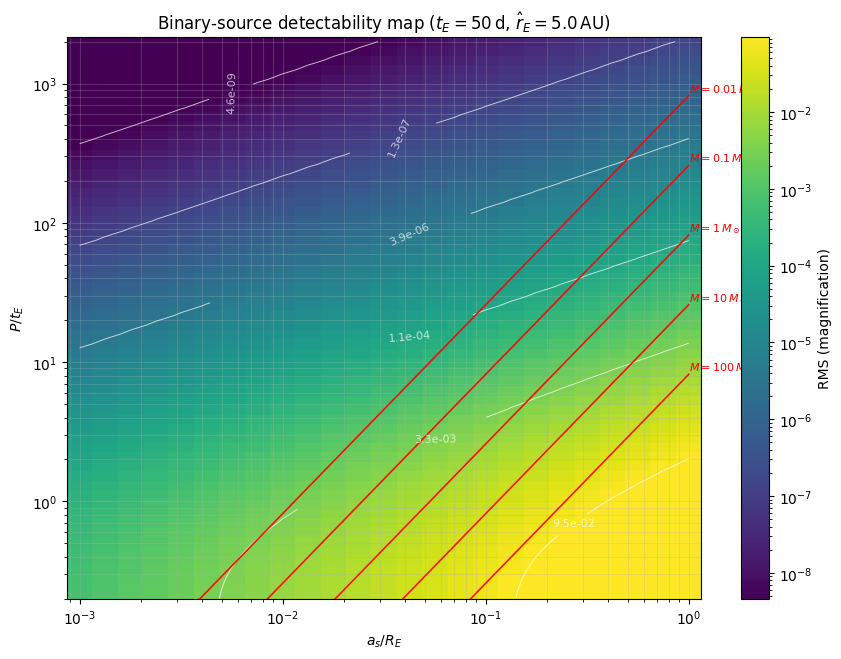

In [11]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ============================================================
# Parámetros de la grilla original
# ============================================================
tE_true = 50.0
rEhat_AU = 5.0

# Estas grillas DEBEN ser las mismas que usaste al generar los archivos
a_over_RE_grid = np.logspace(-3, 0, 25)   # eje x
P_grid_days = np.logspace(1, 5, 60)       # período en días
P_over_tE_grid = P_grid_days / tE_true    # eje y

# Directorio con los .npz
pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_P_tE{int(tE_true)}/scan_aRE_*_P_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Función para extraer índices desde el nombre del archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e ip desde nombres tipo:
    scan_aRE_003_P_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_P_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    ip = int(m.group(2))
    return ia, ip

# ============================================================
# Reconstrucción de la matriz 2D
# ============================================================
Na = len(a_over_RE_grid)
Np = len(P_over_tE_grid)

RMS_map = np.full((Na, Np), np.nan, dtype=float)

for fn in files:
    ia, ip = extract_indices_from_filename(fn)

    if not (0 <= ia < Na and 0 <= ip < Np):
        continue

    d = np.load(fn, allow_pickle=False)

    P_grid_file = d["P_grid"].astype(float)
    RMS = d["RMS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid_file) & np.isfinite(RMS)
    if not np.any(m):
        continue

    rms_val = float(RMS[m][0])
    RMS_map[ia, ip] = rms_val

# ============================================================
# Función para calcular bordes de bins en escala log
# ============================================================
def log_bin_edges(x):
    """
    Devuelve los bordes de bins para una grilla x positiva y monótona,
    asumiendo espaciado aproximadamente logarítmico.
    """
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores de x deben ser > 0 para log_bin_edges.")

    lx = np.log10(x)

    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])

    return 10**edges

a_edges = log_bin_edges(a_over_RE_grid)
p_edges = log_bin_edges(P_over_tE_grid)

# pcolormesh espera matriz con shape (Ny, Nx)
Z = RMS_map.T   # shape = (Np, Na)

# ============================================================
# Preparar normalización logarítmica
# ============================================================
positive = Z[np.isfinite(Z) & (Z > 0)]
if len(positive) == 0:
    raise RuntimeError("No hay valores positivos de RMS para usar LogNorm.")

# Opcional: recorte de percentiles para una visual más prolija
vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)
norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# [BLOQUE NUEVO 4]
# Curvas de masa constante
# ============================================================
def p_over_tE_for_constant_mass(a_over_RE, Mtot_Msun, rEhat_AU, tE_days):
    """
    Devuelve P/tE para una curva de masa total constante Mtot_Msun.

    Usa:
        P_yr^2 = a_AU^3 / Mtot_Msun
    con
        a_AU = a_over_RE * rEhat_AU
        P/tE = P_days / tE_days = (365.25 * P_yr) / tE_days
    """
    a_AU = a_over_RE * rEhat_AU
    P_yr = np.sqrt(a_AU**3 / Mtot_Msun)
    P_days = 365.25 * P_yr
    return P_days / tE_days

# Elegí las masas que te interese mostrar
mass_list = [0.01, 0.1, 1.0, 10.0, 100.0]  # Msun

# ============================================================
# Figura tipo mapa prolijo
# ============================================================
fig, ax = plt.subplots(figsize=(8.8, 6.7))

pcm = ax.pcolormesh(
    a_edges,
    p_edges,
    Z,
    cmap="viridis",
    norm=norm,
    shading="auto"
)

# Contornos opcionales de RMS
Z_contour = np.array(Z, copy=True)
if np.sum(np.isfinite(Z_contour)) > 10:
    zfill = np.nanmin(positive)
    Zc = np.where(np.isfinite(Z_contour), Z_contour, zfill)

    levels = np.geomspace(vmin, vmax, 6)

    cs = ax.contour(
        a_over_RE_grid,
        P_over_tE_grid,
        Zc,
        levels=levels,
        colors="white",
        linewidths=0.7,
        alpha=0.7
    )
    ax.clabel(cs, inline=True, fontsize=8, fmt="%.1e")

# ============================================================
# Curvas de masa constante
# ============================================================
x_curve = np.logspace(np.log10(a_over_RE_grid.min()),
                      np.log10(a_over_RE_grid.max()), 400)

for Mtot in mass_list:
    y_curve = p_over_tE_for_constant_mass(
        a_over_RE=x_curve,
        Mtot_Msun=Mtot,
        rEhat_AU=rEhat_AU,
        tE_days=tE_true
    )

    # recortar a la ventana visible para que no ensucie
    mask = (
        np.isfinite(y_curve) &
        (y_curve >= p_edges.min()) &
        (y_curve <= p_edges.max())
    )

    if np.any(mask):
        ax.plot(
            x_curve[mask],
            y_curve[mask],
            color="red",
            linewidth=1.2,
            alpha=0.9
        )

        # Etiqueta cerca del extremo derecho visible
        idx = np.where(mask)[0][-1]
        ax.text(
            x_curve[idx],
            y_curve[idx],
            rf"$M={Mtot:g}\,M_\odot$",
            color="red",
            fontsize=8,
            ha="left",
            va="bottom"
        )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$a_s/R_E$")
ax.set_ylabel(r"$P/t_E$")
ax.set_title(rf"Binary-source detectability map ($t_E={tE_true:.0f}\,\mathrm{{d}}$, $\hat r_E={rEhat_AU:.1f}\,$AU)")

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"RMS (magnification)")

plt.tight_layout()
plt.show()

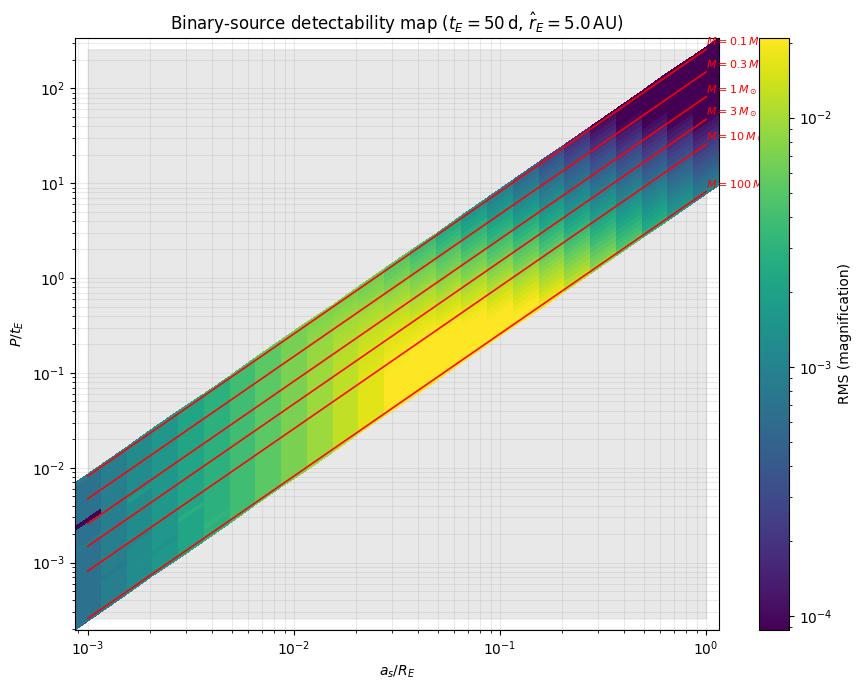

In [34]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ============================================================
# Parámetros del barrido
# ============================================================
tE_true = 50.0
rEhat_AU = 5.0

# Estas grillas DEBEN coincidir con las del script de generación
a_over_RE_grid = np.logspace(-3, 0, 25)
Mtot_grid = np.logspace(-1, 2, 30)   # 0.1 a 10 Msun

# rango "físico" que querés remarcar en la figura
Mmin_phys = 0.1
Mmax_phys = 10.0

pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_Mtot_tE{int(tE_true)}/scan_aRE_*_Mtot_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Parseo de índices desde nombre de archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e im desde:
    scan_aRE_003_Mtot_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_Mtot_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    im = int(m.group(2))
    return ia, im

# ============================================================
# Función para bordes logarítmicos
# ============================================================
def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

# ============================================================
# [BLOQUE AGREGADO 1]
# reconstrucción de matrices en la grilla (a_over_RE, Mtot)
# ============================================================
Na = len(a_over_RE_grid)
Nm = len(Mtot_grid)

RMS_map = np.full((Na, Nm), np.nan, dtype=float)

P_over_tE_map = np.full((Na, Nm), np.nan, dtype=float)

for fn in files:
    ia, im = extract_indices_from_filename(fn)

    if not (0 <= ia < Na and 0 <= im < Nm):
        continue

    d = np.load(fn, allow_pickle=False)

    P_grid_file = d["P_grid"].astype(float)
    RMS = d["RMS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid_file) & np.isfinite(RMS)
    if not np.any(m):
        continue

    P_day = float(P_grid_file[m][0])
    rms_val = float(RMS[m][0])

    RMS_map[ia, im] = rms_val
    P_over_tE_map[ia, im] = P_day / tE_true

# ============================================================
# [BLOQUE AGREGADO 2]
# coordenadas de la grilla en el plano (a_s/R_E, P/t_E)
# ============================================================
# Para cada (a_over_RE, Mtot), el período viene de Kepler:
# P_yr^2 = a_AU^3 / Mtot
A_grid, M_grid = np.meshgrid(a_over_RE_grid, Mtot_grid, indexing="ij")
a_AU_grid = A_grid * rEhat_AU
P_yr_grid = np.sqrt(a_AU_grid**3 / M_grid)
P_day_grid = 365.25 * P_yr_grid
P_over_tE_grid = P_day_grid / tE_true

# ============================================================
# Normalización de color
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No hay valores positivos de RMS para graficar.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)
norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

# ============================================================
# [BLOQUE AGREGADO 3]
# fondo gris no físico
# ============================================================
# En esta versión, toda la figura fuera de [Mmin_phys, Mmax_phys]
# se sombrea construyendo la región delimitada por las curvas de masa.
x_curve = np.logspace(np.log10(a_over_RE_grid.min()),
                      np.log10(a_over_RE_grid.max()), 600)

def p_over_tE_for_constant_mass(a_over_RE, Mtot_Msun, rEhat_AU, tE_days):
    a_AU = a_over_RE * rEhat_AU
    P_yr = np.sqrt(a_AU**3 / Mtot_Msun)
    P_days = 365.25 * P_yr
    return P_days / tE_days

y_mass_min = p_over_tE_for_constant_mass(x_curve, Mmin_phys, rEhat_AU, tE_true)
y_mass_max = p_over_tE_for_constant_mass(x_curve, Mmax_phys, rEhat_AU, tE_true)

# límites visibles aproximados del mapa
ymin_plot = np.nanmin(P_over_tE_grid[np.isfinite(P_over_tE_grid)])
ymax_plot = np.nanmax(P_over_tE_grid[np.isfinite(P_over_tE_grid)])

# región de masas demasiado bajas: P/tE demasiado grande
ax.fill_between(
    x_curve,
    y_mass_min,
    ymax_plot * np.ones_like(x_curve),
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# región de masas demasiado altas: P/tE demasiado chico
ax.fill_between(
    x_curve,
    ymin_plot * np.ones_like(x_curve),
    y_mass_max,
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# ============================================================
# Mapa coloreado: usar celdas deformadas en el plano físico
# ============================================================
# Como las celdas no son rectangulares en (a, P/tE), usamos pcolormesh
# con las coordenadas del centro. Para eso armamos bordes en a y M,
# y los transformamos al plano físico.
a_edges = log_bin_edges(a_over_RE_grid)
m_edges = log_bin_edges(Mtot_grid)

A_edges, M_edges = np.meshgrid(a_edges, m_edges, indexing="ij")
a_AU_edges = A_edges * rEhat_AU
P_yr_edges = np.sqrt(a_AU_edges**3 / M_edges)
P_day_edges = 365.25 * P_yr_edges
P_over_tE_edges = P_day_edges / tE_true

pcm = ax.pcolormesh(
    A_edges,
    P_over_tE_edges,
    RMS_map,
    cmap="viridis",
    norm=norm,
    shading="auto",
    zorder=2
)

# ============================================================
# [BLOQUE AGREGADO 4]
# curvas de masa constante
# ============================================================
mass_list = [0.1, 0.3, 1.0, 3.0, 10.0,100]

for Mtot in mass_list:
    y_curve = p_over_tE_for_constant_mass(x_curve, Mtot, rEhat_AU, tE_true)

    mask = (
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.any(mask):
        ax.plot(
            x_curve[mask],
            y_curve[mask],
            color="red",
            linewidth=1.2,
            alpha=0.95,
            zorder=3
        )

        idx = np.where(mask)[0][-1]
        ax.text(
            x_curve[idx],
            y_curve[idx],
            rf"$M={Mtot:g}\,M_\odot$",
            color="red",
            fontsize=8,
            ha="left",
            va="bottom"
        )

# opcional: remarcar bordes físicos
ax.plot(x_curve, y_mass_min, color="gray", linewidth=1.0, linestyle="--", zorder=1)
ax.plot(x_curve, y_mass_max, color="gray", linewidth=1.0, linestyle="--", zorder=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$a_s/R_E$")
ax.set_ylabel(r"$P/t_E$")
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, $\hat r_E={rEhat_AU:.1f}\,\mathrm{{AU}}$)"
)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"RMS (magnification)")

plt.tight_layout()
plt.savefig("/home/anibal-pc/grid_rms.png")
plt.show()

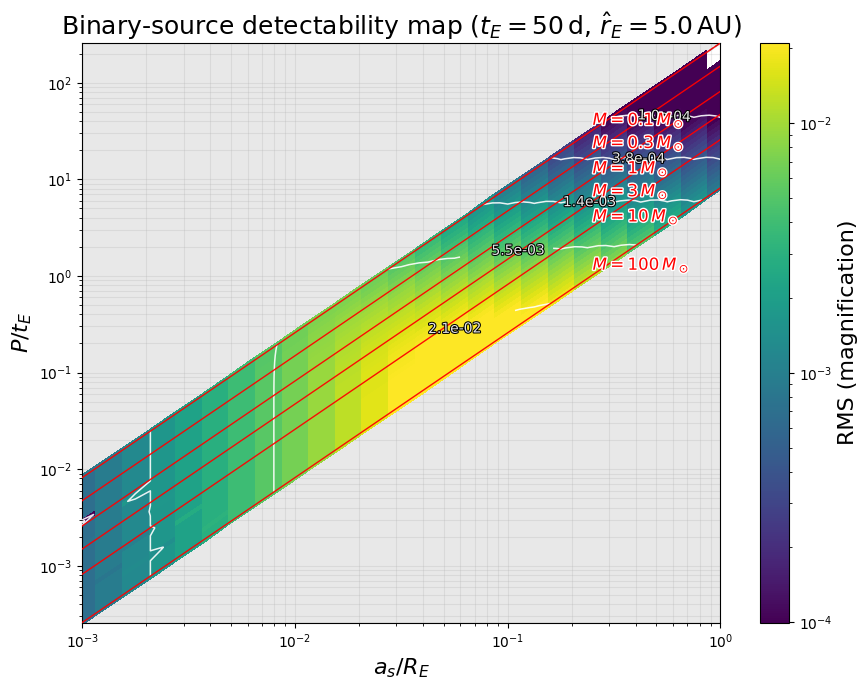

In [41]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patheffects as pe

# ============================================================
# Parámetros del barrido
# ============================================================
tE_true = 50.0
rEhat_AU = 5.0

# Estas grillas DEBEN coincidir con las del script de generación
a_over_RE_grid = np.logspace(-3, 0, 25)
Mtot_grid = np.logspace(-1, 2, 30)   # 0.1 a 100 Msun

# rango "físico" que querés remarcar en la figura
Mmin_phys = 0.1
Mmax_phys = 10.0

pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_Mtot_tE{int(tE_true)}/scan_aRE_*_Mtot_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Parseo de índices desde nombre de archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e im desde:
    scan_aRE_003_Mtot_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_Mtot_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    im = int(m.group(2))
    return ia, im

# ============================================================
# Función para bordes logarítmicos
# ============================================================
def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

# ============================================================
# Reconstrucción de matrices en la grilla (a_over_RE, Mtot)
# ============================================================
Na = len(a_over_RE_grid)
Nm = len(Mtot_grid)

RMS_map = np.full((Na, Nm), np.nan, dtype=float)
P_over_tE_map = np.full((Na, Nm), np.nan, dtype=float)

for fn in files:
    ia, im = extract_indices_from_filename(fn)

    if not (0 <= ia < Na and 0 <= im < Nm):
        continue

    d = np.load(fn, allow_pickle=False)

    P_grid_file = d["P_grid"].astype(float)
    RMS = d["RMS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid_file) & np.isfinite(RMS)
    if not np.any(m):
        continue

    P_day = float(P_grid_file[m][0])
    rms_val = float(RMS[m][0])

    RMS_map[ia, im] = rms_val
    P_over_tE_map[ia, im] = P_day / tE_true

# ============================================================
# Coordenadas de la grilla en el plano (a_s/R_E, P/t_E)
# ============================================================
# Para cada (a_over_RE, Mtot), el período viene de Kepler:
# P_yr^2 = a_AU^3 / Mtot
A_grid, M_grid = np.meshgrid(a_over_RE_grid, Mtot_grid, indexing="ij")
a_AU_grid = A_grid * rEhat_AU
P_yr_grid = np.sqrt(a_AU_grid**3 / M_grid)
P_day_grid = 365.25 * P_yr_grid
P_over_tE_grid = P_day_grid / tE_true

# ============================================================
# [NUEVO BLOQUE 1]
# Limpieza conservadora de artefactos de borde
# ============================================================
# 1) saco no positivos
RMS_map[~np.isfinite(RMS_map)] = np.nan
RMS_map[RMS_map <= 0] = np.nan

positive_all = RMS_map[np.isfinite(RMS_map)]
if len(positive_all) == 0:
    raise RuntimeError("No hay valores positivos de RMS para graficar.")

# umbral muy conservador para valores ultrapequeños de borde
tiny_threshold = np.percentile(positive_all, 0.5)

# máscara de borde
border_mask = np.zeros_like(RMS_map, dtype=bool)
border_mask[0, :] = True
border_mask[-1, :] = True
border_mask[:, 0] = True
border_mask[:, -1] = True

# enmascarar solamente celdas de borde extremadamente pequeñas
RMS_map[border_mask & np.isfinite(RMS_map) & (RMS_map < tiny_threshold)] = np.nan

# si querés ser todavía más agresivo, descomentá una de estas:
# RMS_map[0, :] = np.nan
# RMS_map[:, 0] = np.nan

# ============================================================
# Normalización de color
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No quedaron valores positivos de RMS luego de limpiar el mapa.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)
norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

# ============================================================
# Fondo gris no físico
# ============================================================
x_curve = np.logspace(np.log10(a_over_RE_grid.min()),
                      np.log10(a_over_RE_grid.max()), 800)

def p_over_tE_for_constant_mass(a_over_RE, Mtot_Msun, rEhat_AU, tE_days):
    a_AU = a_over_RE * rEhat_AU
    P_yr = np.sqrt(a_AU**3 / Mtot_Msun)
    P_days = 365.25 * P_yr
    return P_days / tE_days

y_mass_min = p_over_tE_for_constant_mass(x_curve, Mmin_phys, rEhat_AU, tE_true)
y_mass_max = p_over_tE_for_constant_mass(x_curve, Mmax_phys, rEhat_AU, tE_true)

# límites visibles del mapa
finite_p = P_over_tE_grid[np.isfinite(P_over_tE_grid)]
ymin_plot = np.nanmin(finite_p)
ymax_plot = np.nanmax(finite_p)

# región de masas demasiado bajas: P/tE demasiado grande
ax.fill_between(
    x_curve,
    y_mass_min,
    ymax_plot * np.ones_like(x_curve),
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# región de masas demasiado altas: P/tE demasiado chico
ax.fill_between(
    x_curve,
    ymin_plot * np.ones_like(x_curve),
    y_mass_max,
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# ============================================================
# Mapa coloreado: usar celdas deformadas en el plano físico
# ============================================================
a_edges = log_bin_edges(a_over_RE_grid)
m_edges = log_bin_edges(Mtot_grid)

A_edges, M_edges = np.meshgrid(a_edges, m_edges, indexing="ij")
a_AU_edges = A_edges * rEhat_AU
P_yr_edges = np.sqrt(a_AU_edges**3 / M_edges)
P_day_edges = 365.25 * P_yr_edges
P_over_tE_edges = P_day_edges / tE_true

# máscara para pcolormesh
RMS_masked = np.ma.masked_invalid(RMS_map)

# ============================================================
# [NUEVO BLOQUE 4]
# pcolormesh sin bordes ni antialiasing para evitar artefactos
# ============================================================
pcm = ax.pcolormesh(
    A_edges,
    P_over_tE_edges,
    RMS_masked,
    cmap="viridis",
    norm=norm,
    shading="auto",
    edgecolors="none",
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
    zorder=2
)

# ============================================================
# [NUEVO BLOQUE 3]
# Contornos con etiquetas
# ============================================================
# Contornos sobre centros de celda en el plano físico
RMS_for_contour = np.ma.masked_invalid(RMS_map)

# elegí algunos niveles geométricos dentro del rango útil
contour_levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(
    A_grid,
    P_over_tE_grid,
    RMS_for_contour,
    levels=contour_levels,
    colors="white",
    linewidths=1.1,
    alpha=0.9,
    norm=norm,
    zorder=3
)

clabels = ax.clabel(
    cs,
    inline=True,
    fontsize=10,
    fmt=lambda x: f"{x:.1e}"
)

for txt in clabels:
    txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground="black")])

# ============================================================
# [NUEVO BLOQUE 2]
# helper para ubicar etiquetas de masa dentro del panel
# ============================================================
def choose_internal_label_position(x, y, xmin, xmax, ymin, ymax, frac=0.78):
    """
    Busca una posición interna a la figura para etiquetar una curva.
    frac controla en qué fracción del eje x (en log) intentar ubicar la etiqueta.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    valid = (
        np.isfinite(x) & np.isfinite(y) &
        (x >= xmin) & (x <= xmax) &
        (y >= ymin) & (y <= ymax)
    )
    if not np.any(valid):
        return None, None

    xv = x[valid]
    yv = y[valid]

    lxmin, lxmax = np.log10(xmin), np.log10(xmax)
    xtarget = 10**(lxmin + frac * (lxmax - lxmin))

    idx = np.argmin(np.abs(np.log10(xv) - np.log10(xtarget)))
    return xv[idx], yv[idx]

# ============================================================
# Curvas de masa constante
# ============================================================
mass_list = [0.1, 0.3, 1.0, 3.0, 10.0, 100.0]

xmin_plot = a_over_RE_grid.min()
xmax_plot = a_over_RE_grid.max()

for Mtot in mass_list:
    y_curve = p_over_tE_for_constant_mass(x_curve, Mtot, rEhat_AU, tE_true)

    mask = (
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.any(mask):
        ax.plot(
            x_curve[mask],
            y_curve[mask],
            color="red",
            linewidth=1,
            alpha=0.95,
            zorder=4
        )

        # etiqueta adentro del panel
        xlab, ylab = choose_internal_label_position(
            x_curve[mask], y_curve[mask],
            xmin=xmin_plot, xmax=xmax_plot,
            ymin=ymin_plot, ymax=ymax_plot,
            frac=0.80
        )

        if xlab is not None:
            label = rf"$M={Mtot:g}\,M_\odot$"
            txt = ax.text(
                xlab,
                ylab,
                label,
                color="red",
                fontsize=12,
                ha="left",
                va="bottom",
                zorder=5
            )
            txt.set_path_effects([pe.withStroke(linewidth=2.0, foreground="white")])

# remarcar bordes físicos
ax.plot(x_curve, y_mass_min, color="gray", linewidth=1.0, linestyle="--", zorder=1)
ax.plot(x_curve, y_mass_max, color="gray", linewidth=1.0, linestyle="--", zorder=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$a_s/R_E$",fontsize=16)
ax.set_ylabel(r"$P/t_E$",fontsize=16)
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, $\hat r_E={rEhat_AU:.1f}\,\mathrm{{AU}}$)",fontsize=18
)

ax.set_xlim(xmin_plot, xmax_plot)
ax.set_ylim(ymin_plot, ymax_plot)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"RMS (magnification)",fontsize=16)

plt.tight_layout()
plt.savefig("/home/anibal-pc/grid_rms.png", dpi=250, bbox_inches="tight")
plt.show()

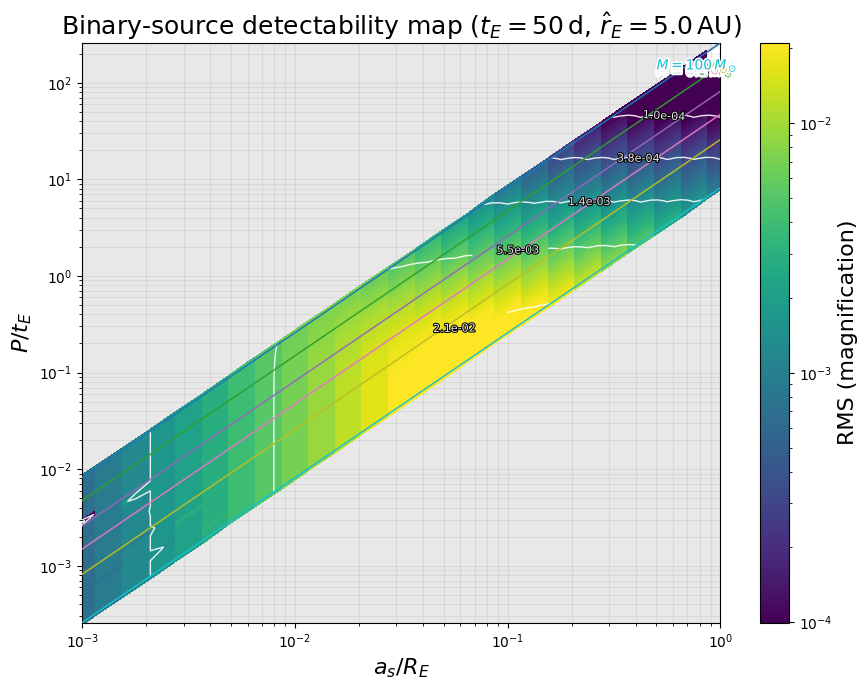

In [42]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patheffects as pe

# ============================================================
# Parámetros del barrido
# ============================================================
tE_true = 50.0
rEhat_AU = 5.0

# Estas grillas DEBEN coincidir con las del script de generación
a_over_RE_grid = np.logspace(-3, 0, 25)
Mtot_grid = np.logspace(-1, 2, 30)   # 0.1 a 100 Msun

# rango "físico" que querés remarcar en la figura
Mmin_phys = 0.1
Mmax_phys = 10.0

pattern = f"/home/anibal-pc/binary_source/results/scan_aRE_Mtot_tE{int(tE_true)}/scan_aRE_*_Mtot_*.npz"
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

# ============================================================
# Parseo de índices desde nombre de archivo
# ============================================================
def extract_indices_from_filename(filename):
    """
    Extrae ia e im desde:
    scan_aRE_003_Mtot_015.npz
    """
    base = os.path.basename(filename)
    m = re.match(r"scan_aRE_(\d+)_Mtot_(\d+)\.npz", base)
    if m is None:
        raise ValueError(f"No pude parsear índices desde: {base}")
    ia = int(m.group(1))
    im = int(m.group(2))
    return ia, im

# ============================================================
# Función para bordes logarítmicos
# ============================================================
def log_bin_edges(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("Todos los valores deben ser positivos.")
    lx = np.log10(x)
    edges = np.empty(len(x) + 1, dtype=float)
    edges[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    edges[0] = lx[0] - 0.5 * (lx[1] - lx[0])
    edges[-1] = lx[-1] + 0.5 * (lx[-1] - lx[-2])
    return 10**edges

# ============================================================
# Reconstrucción de matrices en la grilla (a_over_RE, Mtot)
# ============================================================
Na = len(a_over_RE_grid)
Nm = len(Mtot_grid)

RMS_map = np.full((Na, Nm), np.nan, dtype=float)
P_over_tE_map = np.full((Na, Nm), np.nan, dtype=float)

for fn in files:
    ia, im = extract_indices_from_filename(fn)

    if not (0 <= ia < Na and 0 <= im < Nm):
        continue

    d = np.load(fn, allow_pickle=False)

    P_grid_file = d["P_grid"].astype(float)
    RMS = d["RMS"].astype(float)
    SUCCESS = d["SUCCESS"].astype(bool)

    m = SUCCESS & np.isfinite(P_grid_file) & np.isfinite(RMS)
    if not np.any(m):
        continue

    P_day = float(P_grid_file[m][0])
    rms_val = float(RMS[m][0])

    RMS_map[ia, im] = rms_val
    P_over_tE_map[ia, im] = P_day / tE_true

# ============================================================
# Coordenadas de la grilla en el plano (a_s/R_E, P/t_E)
# ============================================================
A_grid, M_grid = np.meshgrid(a_over_RE_grid, Mtot_grid, indexing="ij")
a_AU_grid = A_grid * rEhat_AU
P_yr_grid = np.sqrt(a_AU_grid**3 / M_grid)
P_day_grid = 365.25 * P_yr_grid
P_over_tE_grid = P_day_grid / tE_true

# ============================================================
# Limpieza conservadora de artefactos de borde
# ============================================================
RMS_map[~np.isfinite(RMS_map)] = np.nan
RMS_map[RMS_map <= 0] = np.nan

positive_all = RMS_map[np.isfinite(RMS_map)]
if len(positive_all) == 0:
    raise RuntimeError("No hay valores positivos de RMS para graficar.")

tiny_threshold = np.percentile(positive_all, 0.5)

border_mask = np.zeros_like(RMS_map, dtype=bool)
border_mask[0, :] = True
border_mask[-1, :] = True
border_mask[:, 0] = True
border_mask[:, -1] = True

RMS_map[border_mask & np.isfinite(RMS_map) & (RMS_map < tiny_threshold)] = np.nan

# ============================================================
# Normalización de color
# ============================================================
positive = RMS_map[np.isfinite(RMS_map) & (RMS_map > 0)]
if len(positive) == 0:
    raise RuntimeError("No quedaron valores positivos de RMS luego de limpiar el mapa.")

vmin = np.percentile(positive, 5)
vmax = np.percentile(positive, 95)
norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ============================================================
# Figura
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

# ============================================================
# Fondo gris no físico
# ============================================================
x_curve = np.logspace(np.log10(a_over_RE_grid.min()),
                      np.log10(a_over_RE_grid.max()), 800)

def p_over_tE_for_constant_mass(a_over_RE, Mtot_Msun, rEhat_AU, tE_days):
    a_AU = a_over_RE * rEhat_AU
    P_yr = np.sqrt(a_AU**3 / Mtot_Msun)
    P_days = 365.25 * P_yr
    return P_days / tE_days

y_mass_min = p_over_tE_for_constant_mass(x_curve, Mmin_phys, rEhat_AU, tE_true)
y_mass_max = p_over_tE_for_constant_mass(x_curve, Mmax_phys, rEhat_AU, tE_true)

finite_p = P_over_tE_grid[np.isfinite(P_over_tE_grid)]
ymin_plot = np.nanmin(finite_p)
ymax_plot = np.nanmax(finite_p)

# región de masas demasiado bajas: P/tE demasiado grande
ax.fill_between(
    x_curve,
    y_mass_min,
    ymax_plot * np.ones_like(x_curve),
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# región de masas demasiado altas: P/tE demasiado chico
ax.fill_between(
    x_curve,
    ymin_plot * np.ones_like(x_curve),
    y_mass_max,
    color="lightgray",
    alpha=0.5,
    zorder=0
)

# ============================================================
# Mapa coloreado
# ============================================================
a_edges = log_bin_edges(a_over_RE_grid)
m_edges = log_bin_edges(Mtot_grid)

A_edges, M_edges = np.meshgrid(a_edges, m_edges, indexing="ij")
a_AU_edges = A_edges * rEhat_AU
P_yr_edges = np.sqrt(a_AU_edges**3 / M_edges)
P_day_edges = 365.25 * P_yr_edges
P_over_tE_edges = P_day_edges / tE_true

RMS_masked = np.ma.masked_invalid(RMS_map)

pcm = ax.pcolormesh(
    A_edges,
    P_over_tE_edges,
    RMS_masked,
    cmap="viridis",
    norm=norm,
    shading="auto",
    edgecolors="none",
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
    zorder=2
)

# ============================================================
# Contornos con etiquetas
# ============================================================
RMS_for_contour = np.ma.masked_invalid(RMS_map)

contour_levels = np.geomspace(vmin, vmax, 5)

cs = ax.contour(
    A_grid,
    P_over_tE_grid,
    RMS_for_contour,
    levels=contour_levels,
    colors="white",
    linewidths=1.0,
    alpha=0.9,
    norm=norm,
    zorder=3
)

clabels = ax.clabel(
    cs,
    inline=True,
    fontsize=8,
    fmt=lambda x: f"{x:.1e}"
)

for txt in clabels:
    txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground="black")])

# ============================================================
# [NUEVO BLOQUE A]
# colores distintos para cada curva de masa
# ============================================================
mass_list = [0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
mass_colors = plt.cm.tab10(np.linspace(0, 1, len(mass_list)))

# ============================================================
# [NUEVO BLOQUE B]
# función para ubicar labels en la región gris superior
# ============================================================
def choose_label_in_upper_gray_region(x_curve, y_curve, y_mass_min_curve, frac_x=0.88, y_factor=1.18):
    """
    Busca una posición en la región gris superior, ligeramente por encima
    de la curva de masa mínima física.
    """
    lx = np.log10(x_curve)
    xtarget = 10 ** (lx.min() + frac_x * (lx.max() - lx.min()))
    idx = np.argmin(np.abs(np.log10(x_curve) - np.log10(xtarget)))

    xlab = x_curve[idx]
    ybase = y_mass_min_curve[idx]
    ylab = ybase * y_factor

    if ylab >= ymax_plot:
        ylab = ybase * 1.08

    if ylab <= ybase:
        return None, None

    return xlab, ylab

# ============================================================
# [NUEVO BLOQUE C]
# curvas de masa constante + labels en la zona gris
# ============================================================
xmin_plot = a_over_RE_grid.min()
xmax_plot = a_over_RE_grid.max()

for i, Mtot in enumerate(mass_list):
    curve_color = mass_colors[i]
    y_curve = p_over_tE_for_constant_mass(x_curve, Mtot, rEhat_AU, tE_true)

    mask = (
        np.isfinite(y_curve) &
        (y_curve >= ymin_plot) &
        (y_curve <= ymax_plot)
    )

    if np.any(mask):
        ax.plot(
            x_curve[mask],
            y_curve[mask],
            color=curve_color,
            linewidth=1.1,
            alpha=0.95,
            zorder=4
        )

        # label en la región gris superior
        xlab, ylab = choose_label_in_upper_gray_region(
            x_curve, y_curve, y_mass_min, frac_x=0.90, y_factor=1.15 + 0.04 * i
        )

        if xlab is not None and (ylab < ymax_plot):
            label = rf"$M={Mtot:g}\,M_\odot$"
            txt = ax.text(
                xlab,
                ylab,
                label,
                color=curve_color,
                fontsize=10,
                ha="left",
                va="bottom",
                zorder=6
            )
            txt.set_path_effects([pe.withStroke(linewidth=2.2, foreground="white")])

# remarcar bordes físicos
ax.plot(x_curve, y_mass_min, color="gray", linewidth=1.0, linestyle="--", zorder=1)
ax.plot(x_curve, y_mass_max, color="gray", linewidth=1.0, linestyle="--", zorder=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$a_s/R_E$", fontsize=16)
ax.set_ylabel(r"$P/t_E$", fontsize=16)
ax.set_title(
    rf"Binary-source detectability map "
    rf"($t_E={tE_true:.0f}\,\mathrm{{d}}$, $\hat r_E={rEhat_AU:.1f}\,\mathrm{{AU}}$)",
    fontsize=18
)

ax.set_xlim(xmin_plot, xmax_plot)
ax.set_ylim(ymin_plot, ymax_plot)

ax.grid(True, which="both", alpha=0.25)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"RMS (magnification)", fontsize=16)

plt.tight_layout()
plt.savefig("/home/anibal-pc/grid_rms.png", dpi=250, bbox_inches="tight")
plt.show()